# UMAP projection of opinion embeddings

`design.md`'s read path ends with a **2D projection** of the matched embeddings, which is what
the client-side visualization of the opinion space is drawn from. Nothing in the app computes
that projection yet — this notebook is where the projection is tried out before it is wired
into `/search/`.

What it does, in order:

1. boots Django against the local development database,
2. loads `opinions/tests/fixtures/sample_opinions.json` into it, so there is something to look at,
3. runs **the same query `/search/` runs** — `opinions.search.search_opinions(query, max_distance)`,
   the query text and the slider value being the two knobs,
4. projects the matched 1024-dim BGE-M3 embeddings down to 2D with UMAP, and plots them.

Before running, note that:

- it **writes to the development database** named in `.env` (the fixture's opinions), not to a
  throwaway test database. It only ever touches rows whose text comes from the fixture.
- the first cell that embeds anything loads BGE-M3 (multi-GB, downloaded on first use). Expect
  the fixture-loading cell to sit there for a while the first time.
- `uv sync` installs `umap-learn`, `matplotlib` and `jupyterlab` from the dev group; start this
  with `uv run jupyter lab`.

## 1. Boot Django

In [1]:
import os
import sys
from pathlib import Path

# The notebook lives in notebooks/, the Django project one level up. settings.py
# resolves .env relative to itself, so only sys.path and the settings module matter here.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "opinionsearch.settings")
# IPython runs cells inside an event loop, and Django refuses synchronous ORM
# calls from an async context unless this is set. Safe here (one notebook, one
# thread, no concurrency); it is exactly the escape hatch Django documents for
# Jupyter, and must be set before django.setup().
os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "1")

import django

django.setup()

from django.conf import settings

print("database:", settings.DATABASES["default"]["NAME"])

/home/leo/ETH/opinionsearch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


database: opinionsearch


## 2. Load the sample opinions

`opinions.tests.utils.load_opinions_fixture` is the same loader the test session uses: it
embeds every statement in **one** batched BGE-M3 call rather than one call per statement.

Unlike `opinions/tests/integration/conftest.py` — which wipes `Opinion` outright, because it owns its
database — this only removes rows whose text comes from the fixture, so any opinions you
created by hand in the development database survive. Set `RELOAD_FIXTURE = True` to force a
re-insert (e.g. after editing the fixture).

In [2]:
import json

from opinions.models import Opinion, User
from opinions.tests.utils import load_opinions_fixture

FIXTURE_PATH = REPO_ROOT / "opinions" / "tests" / "fixtures" / "sample_opinions.json"
RELOAD_FIXTURE = False

fixture_texts = {s["text"] for s in json.loads(FIXTURE_PATH.read_text())["statements"]}
already_loaded = Opinion.objects.filter(text__in=fixture_texts)

if RELOAD_FIXTURE:
    already_loaded.delete()

if not Opinion.objects.filter(text__in=fixture_texts).exists():
    # First call into BGE-M3 in this process: the model loads here.
    load_opinions_fixture(FIXTURE_PATH)
    print("fixture loaded")
else:
    print("fixture already present, skipping (set RELOAD_FIXTURE = True to reload)")

print(f"{Opinion.objects.count()} opinions, {User.objects.count()} users in the database")

fixture already present, skipping (set RELOAD_FIXTURE = True to reload)
19 opinions, 5 users in the database


## 3. Fetch opinions the way `/search/` does

`opinions.search.search_opinions` is the query behind the `/search/` page — the view is only
request parsing and rendering on top of it. Calling it here means the notebook is projecting
*the result set the page would show*, not a look-alike of it.

The two knobs are the page's two form fields:

- `query` — the statement typed into the text box, embedded with the same document embedding
  function used for stored opinions;
- `max_distance` — the slider, a maximum **cosine** distance in `[0, 1]`. `0` keeps only
  exact-embedding matches, `1` keeps essentially everything.

`search_opinions` returns a lazy `QuerySet` annotated with `distance`, so it can still be
chained — `select_related("author")` below turns N author lookups into one join.

In [11]:
import numpy as np

from opinions.embedding import embed_text
from opinions.models import EMBEDDING_DIM
from opinions.search import DEFAULT_MAX_DISTANCE, search_opinions


def fetch_search_results(query, max_distance=DEFAULT_MAX_DISTANCE):
    """Run the /search/ query and return its embeddings plus row metadata.

    Returns ``(embeddings, rows)``: an ``(n, EMBEDDING_DIM)`` float array in the
    page's own nearest-first order, and a list of dicts describing each row.
    """
    opinions = list(search_opinions(query, max_distance).select_related("author"))
    embeddings = (
        np.vstack([opinion.embedding for opinion in opinions])
        if opinions
        else np.empty((0, EMBEDDING_DIM))
    )
    rows = [
        {
            "text": opinion.text,
            "topic": opinion.topic,
            "author": opinion.author.username,
            "distance": float(opinion.distance),
            "similarity": 1 - float(opinion.distance),
        }
        for opinion in opinions
    ]
    return embeddings, rows


def fetch_all_opinions():
    """Every embedded opinion, ignoring the query -- the whole map rather than one search."""
    opinions = list(
        Opinion.objects.exclude(embedding=None).select_related("author").order_by("pk")
    )
    embeddings = np.vstack([opinion.embedding for opinion in opinions])
    rows = [
        {
            "text": opinion.text,
            "topic": opinion.topic,
            "author": opinion.author.username,
        }
        for opinion in opinions
    ]
    return embeddings, rows


QUERY = "We must cut carbon emissions faster through a nationwide carbon tax."
MAX_DISTANCE = 1.0  # the slider, wide open: project the whole result set

## 4. Choosing UMAP's parameters

From the [UMAP parameter guide](https://umap-learn.readthedocs.io/en/latest/parameters.html)
and [UMAP for clustering](https://umap-learn.readthedocs.io/en/latest/clustering.html),
applied to this dataset:

| parameter | value here | why |
| --- | --- | --- |
| `n_components` | `2` | The projection exists to be plotted. (For *clustering* the docs suggest projecting to 10+ dimensions and clustering there — that would be a separate reducer from this one.) |
| `metric` | `"cosine"` | The default is `euclidean`, but everything else in this project compares BGE-M3 vectors by angle: the search uses `CosineDistance`, and `Opinion`'s HNSW index is built with `vector_cosine_ops`. Matching the metric keeps the picture consistent with the ranking. |
| `n_neighbors` | `15` for looking, `30` for clustering | "controls how UMAP balances local versus global structure": low values (2) keep fine local detail and lose the global picture, high values (200) do the reverse; the docs' general range is 2–100. The clustering guide raises it to 30 because "small values … are more prone to producing fine grained cluster structure that may be more a result of patterns of noise". |
| `min_dist` | `0.1` for looking, `0.0` for clustering | How tightly points may be packed. `0.0` gives the clumped, well-separated blobs a density-based clusterer wants; the `0.1` default spreads points out so overlapping opinions stay individually readable. |
| `random_state` | `42` | Reproducibility. Note the API docs' caveat: running in parallel "is not used if a random seed has been set", so a fixed seed costs speed on large inputs. Irrelevant at this size, and worth keeping while tuning so a changed picture means a changed parameter. |

**The sample-code values (`n_neighbors=30`, `min_dist=0.0`) come from the clustering guide,
not the visualization one** — they are the right starting point given design.md clusters the
opinion space, but they were written for MNIST's 70,000 points.

**The real constraint here is size.** `n_neighbors` cannot exceed `n_samples - 1`; UMAP
truncates it with a warning if it does. The fixture holds 16 statements, so a request for 30
neighbours silently becomes "every other point", and the layout stops being a *local* manifold
approximation at all — it's closer to a plain force-directed scatter. Treat the pictures below
as a smoke test of the pipeline, not as evidence about the shape of the opinion space; the
parameters are worth re-tuning once there are hundreds of opinions to project.

In [15]:
import warnings

import umap


def project(
    embeddings,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
    **kwargs,
):
    """Project embeddings to 2D, clamping n_neighbors to what the dataset supports.

    Returns ``(coords, reducer)``. The fitted reducer is handed back because a
    real deployment would fit once over the corpus and then call
    ``reducer.transform`` on new opinions, rather than refitting per search.
    """
    n_samples = len(embeddings)

    effective_neighbors = max(2, min(n_neighbors, n_samples - 1))
    if effective_neighbors != n_neighbors:
        warnings.warn(
            f"n_neighbors={n_neighbors} exceeds the {n_samples}-point dataset; "
            f"using {effective_neighbors}."
        )

    reducer = umap.UMAP(
        n_neighbors=effective_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric=metric,
        random_state=random_state,
        **kwargs,
    )
    return reducer.fit_transform(embeddings), reducer

## 5. Plotting

In [16]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["figure.dpi"] = 110


def category_colors(rows, color_by="topic"):
    """One tab10 colour per distinct value of ``color_by``, stable across plots."""
    categories = sorted({row[color_by] for row in rows})
    palette = plt.get_cmap("tab10")
    return {category: palette(i % 10) for i, category in enumerate(categories)}


def legend_handles(colors, include_query=False):
    """Proxy handles, so faded points still get a full-strength legend swatch."""
    handles = [
        Line2D([], [], marker="o", linestyle="none", color=color, label=category)
        for category, color in colors.items()
    ]
    if include_query:
        handles.append(
            Line2D(
                [], [], marker="*", linestyle="none", color="black",
                markersize=12, label="query",
            )
        )
    return handles


def plot_projection(
    coords,
    rows,
    color_by="topic",
    annotate=True,
    highlight=None,
    query_point=None,
    title=None,
    legend=True,
    ax=None,
):
    """Scatter a 2D projection, one colour per distinct value of ``color_by``.

    ``highlight`` is an optional boolean mask (e.g. "matched the search"); points
    outside it are drawn faded rather than dropped, so the search reads as a region
    of the map. ``query_point`` is an optional ``(x, y)`` for the query itself,
    drawn as a black star.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    colors = category_colors(rows, color_by)
    labels = np.array([row[color_by] for row in rows])
    if highlight is None:
        highlight = np.ones(len(rows), dtype=bool)

    for category, color in colors.items():
        for matched, alpha, size in ((True, 0.95, 70), (False, 0.18, 40)):
            mask = (labels == category) & (highlight == matched)
            if mask.any():
                ax.scatter(
                    coords[mask, 0], coords[mask, 1],
                    color=color, alpha=alpha, s=size, edgecolors="none",
                )

    if query_point is not None:
        ax.scatter(*query_point, marker="*", s=320, color="black", zorder=5)

    if annotate:
        for (x, y), row in zip(coords, rows):
            ax.annotate(
                row["text"][:34] + ("\u2026" if len(row["text"]) > 34 else ""),
                (x, y), fontsize=6, alpha=0.75,
                xytext=(4, 3), textcoords="offset points",
            )

    ax.set_title(title or "UMAP projection of opinion embeddings", fontsize=10)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    # The axes of a UMAP embedding carry no units and mean nothing individually;
    # only relative position does. Drop the ticks so they aren't read as data.
    ax.set_xticks([])
    ax.set_yticks([])
    if legend:
        # Outside the axes: with this few points, "best" still lands on top of them.
        ax.legend(
            handles=legend_handles(colors, include_query=query_point is not None),
            fontsize=8,
            loc="upper left",
            bbox_to_anchor=(1.01, 1.0),
            frameon=False,
        )
    return ax

## 6. Project one search's results

The visualization parameters (`n_neighbors=15`, `min_dist=0.1`) — points stay far enough apart
to read individually.

  0.0000  [climate policy] We must cut carbon emissions faster through a nationwide car
  0.0000  [climate policy] We must cut carbon emissions faster through a nationwide car
  0.3256  [climate policy] Nuclear power should be expanded to replace coal plants quic
  0.3743  [climate policy] International climate agreements need real enforcement mecha
  0.3845  [climate policy] Climate policy should prioritize protecting low-income commu


/home/leo/ETH/opinionsearch/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  0.0000  [climate policy] We must cut carbon emissions faster through a nationwide car
  0.0000  [climate policy] We must cut carbon emissions faster through a nationwide car
  0.3256  [climate policy] Nuclear power should be expanded to replace coal plants quic
  0.3743  [climate policy] International climate agreements need real enforcement mecha
  0.3845  [climate policy] Climate policy should prioritize protecting low-income commu


/home/leo/ETH/opinionsearch/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  0.0000  [climate policy] We must cut carbon emissions faster through a nationwide car
  0.0000  [climate policy] We must cut carbon emissions faster through a nationwide car
  0.3256  [climate policy] Nuclear power should be expanded to replace coal plants quic
  0.3743  [climate policy] International climate agreements need real enforcement mecha
  0.3845  [climate policy] Climate policy should prioritize protecting low-income commu


/home/leo/ETH/opinionsearch/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


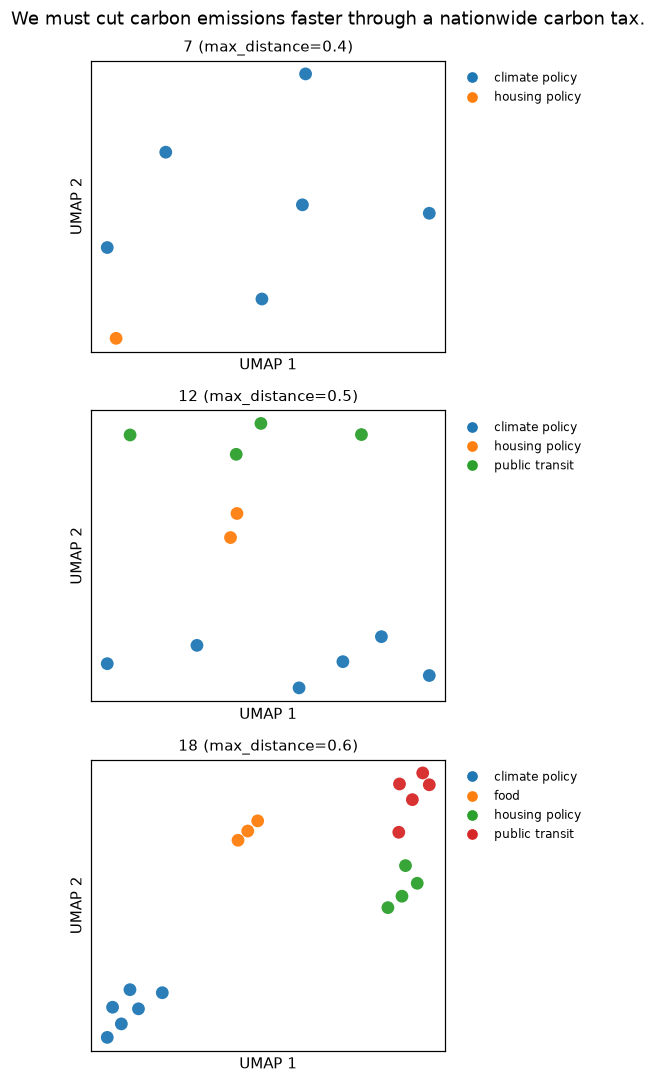

In [26]:
fig, axs = plt.subplots(3, 1, figsize=(5, 10))
deg = np.arange(0.4, 0.7, 0.1)
for ax, max_distance in zip(axs, deg):
    embeddings, rows = fetch_search_results(QUERY, max_distance)
    for row in rows[:5]:
        print(f"  {row['distance']:.4f}  [{row['topic']}] {row['text'][:60]}")
        
    coords, reducer = project(embeddings, n_neighbors=4, min_dist=0.1)
    plot_projection(
        coords,
        rows,
        title=f"{len(rows)} (max_distance={max_distance})",
        annotate=False,
        ax=ax
    )
fig.suptitle(QUERY)
plt.tight_layout()
plt.show()

## 7. Sweep the two parameters that matter

`n_neighbors` (local ↔ global) against `min_dist` (packed ↔ spread), everything else fixed.
This is the cell to come back to once the corpus is bigger: pick the pair whose layout matches
the structure you can verify by reading the statements.

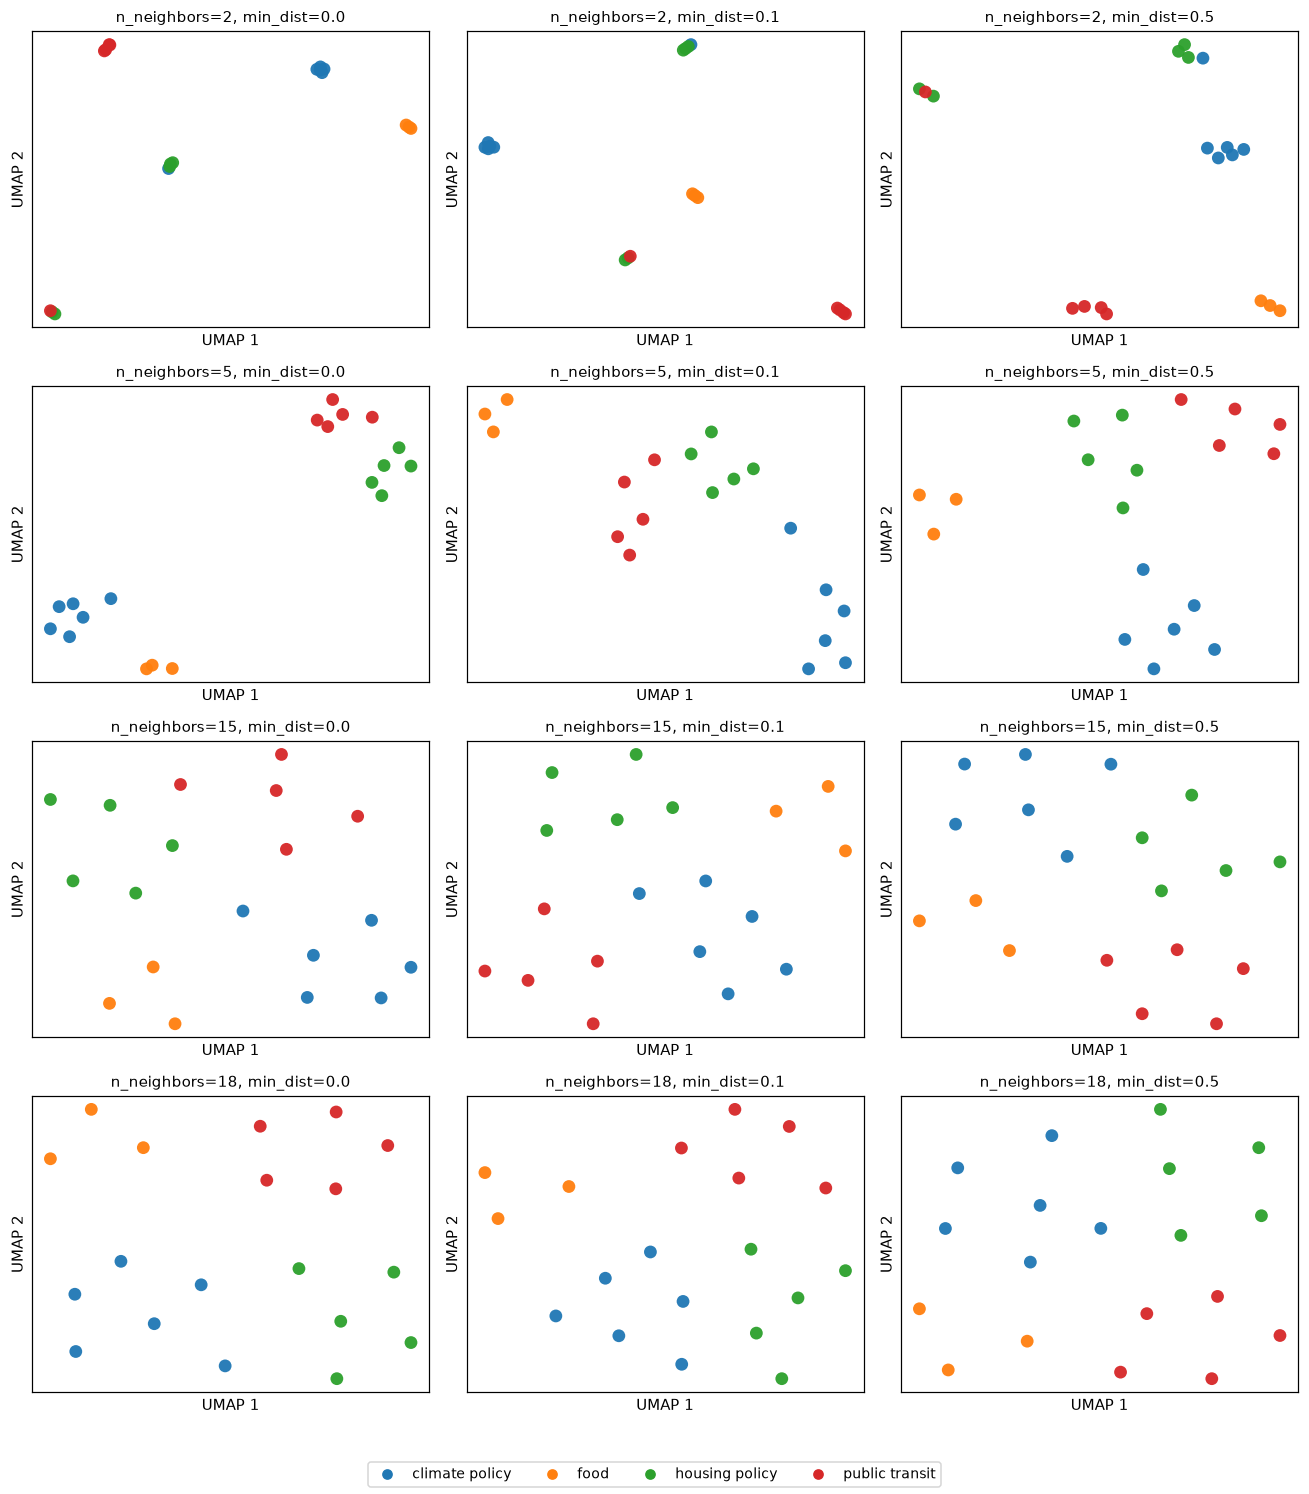

In [7]:
neighbor_values = [2, 5, 15, min(30, len(embeddings) - 1)]
min_dist_values = [0.0, 0.1, 0.5]

fig, axes = plt.subplots(
    len(neighbor_values),
    len(min_dist_values),
    figsize=(4 * len(min_dist_values), 3.4 * len(neighbor_values)),
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # the n_neighbors clamp, once per panel
    for row_index, n_neighbors in enumerate(neighbor_values):
        for col_index, min_dist in enumerate(min_dist_values):
            sweep_coords, _ = project(
                embeddings, n_neighbors=n_neighbors, min_dist=min_dist
            )
            plot_projection(
                sweep_coords,
                rows,
                annotate=False,
                legend=False,
                title=f"n_neighbors={n_neighbors}, min_dist={min_dist}",
                ax=axes[row_index][col_index],
            )

handles = legend_handles(category_colors(rows))
fig.legend(handles=handles, loc="lower center", ncol=len(handles), fontsize=9)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### What the sweep says about *this* corpus

Read the panels by whether same-topic statements land together (the topic label is metadata
UMAP never sees, so it's a free check on the layout):

- `n_neighbors=2` collapses everything into a few tight knots — it is modelling pairs, not a
  manifold, and mixes topics inside a knot.
- **`n_neighbors=5` is where the four topics separate cleanly**, with `min_dist` between `0.0`
  and `0.1` keeping the groups compact.
- `n_neighbors=15` and above wash out into a near-uniform scatter with topics interleaved. That
  is the `n_samples` ceiling biting: with 19 points, "15 nearest neighbours" is most of the
  dataset, so every point's neighbourhood is the same neighbourhood and there is no local
  structure left to preserve.

So the sample code's `n_neighbors=30` is not merely clamped here, it is actively wrong for this
input — and `5` is not a recommendation either, it is roughly `n_samples / 4`. The honest
reading is that **this corpus is too small to tune against**; what the sweep establishes is that
the pipeline works and how to re-run the tuning once there are hundreds of opinions, at which
point the clustering guide's `n_neighbors=30, min_dist=0.0` becomes a sensible starting point
again.

## 8. The whole map, with one search highlighted

Closer to what the product actually shows: the projection is fit over **every** opinion, and a
search highlights a region of that fixed map rather than producing a new layout of its own.
That distinction matters — UMAP fit on a filtered subset gives coordinates that can't be
compared across searches, whereas a corpus-wide fit gives every opinion one stable position.

The query's own embedding is projected alongside the opinions (fit together with them, so the
star lands in the same coordinate space) to show where the search sits on the map. Don't
over-read its exact position: `min_dist` pushes neighbours apart whether or not their vectors
differ, so even the two opinions at distance `0.0000` from the query don't land on the same
pixel. Read regions, not coordinates.

/home/leo/ETH/opinionsearch/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


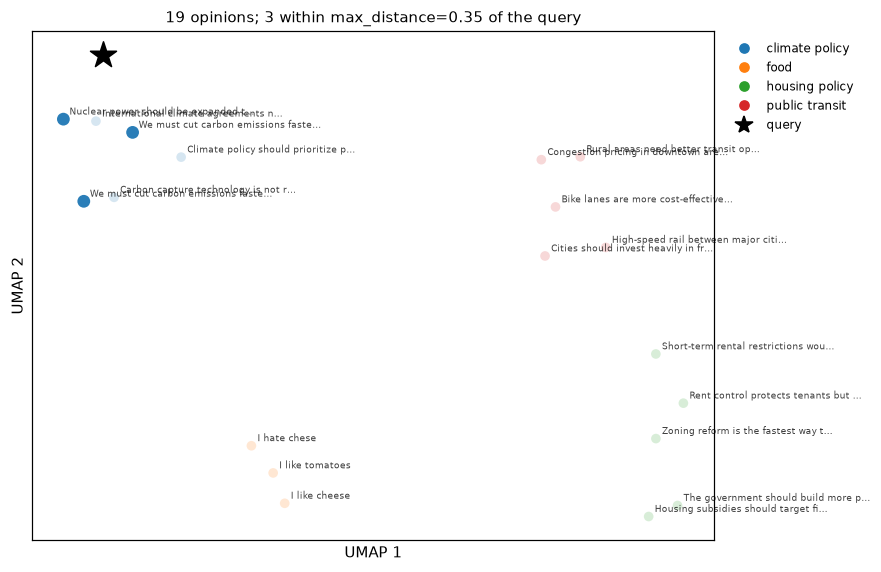

In [8]:
HIGHLIGHT_MAX_DISTANCE = 0.35  # the slider, this time actually filtering

all_embeddings, all_rows = fetch_all_opinions()
_, matched_rows = fetch_search_results(QUERY, HIGHLIGHT_MAX_DISTANCE)
matched_texts = {row["text"] for row in matched_rows}
highlight = np.array([row["text"] in matched_texts for row in all_rows])

# Fit over the corpus plus the query point, then split the query back off.
query_embedding = np.asarray(embed_text(QUERY)).reshape(1, -1)
combined_coords, corpus_reducer = project(
    np.vstack([all_embeddings, query_embedding]),
    n_neighbors=5,  # what the sweep above showed for a corpus this size
    min_dist=0.1,
)
corpus_coords, query_coords = combined_coords[:-1], combined_coords[-1]

plot_projection(
    corpus_coords,
    all_rows,
    highlight=highlight,
    query_point=query_coords,
    title=(
        f"{len(all_rows)} opinions; {highlight.sum()} within "
        f"max_distance={HIGHLIGHT_MAX_DISTANCE} of the query"
    ),
)
plt.show()

## Carrying this into the app

Notes for turning the above into the read path `design.md` describes:

- **Fit once, transform many.** Refitting UMAP per search is both slow and unstable — the
  coordinates would jump between searches. Fit a reducer over the corpus offline (alongside the
  clustering step, which also doesn't exist yet), persist it, and call `reducer.transform()` for
  opinions added afterwards. Projected coordinates then belong on the `Opinion` row, next to
  `cluster`, so a search returns them by joining rather than by computing.
- **`umap-learn` is a dev-group dependency right now**, because nothing the app serves imports
  it. Moving the projection into the request path means promoting it to a runtime dependency.
- **Re-tune once the corpus is real.** Every parameter above was picked against 16–20 points,
  which is below the size where `n_neighbors` means anything. Section 7 is the cell to rerun.
- **`random_state` costs parallelism.** Keep the fixed seed for a stored, offline fit (stable
  pictures matter more than fit time); drop it only if fitting becomes a bottleneck.